#   Ανάλυση Βιο-δεδομένων

#  Synthetic Medical Data Generation: Opportunities and Challenges for GenAI-Based Augmentation

Βάση Δεδομένων: Diabetes Health Indicators Dataset

https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset



Μέλη Ομάδας:

- 03400305 - Παντελεήμων Ναούμ
- 03400288 - Ανδρέας Γκανάς
- 03400289 - Κερκύρα Δημησίανου

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as ms

##  Exploratory Data Analysis (EDA)

Αρχικά πραγματοποιείται import των δεδομένων και EDA.

Θα χρησιμοποιηθεί το dataset από το αρχείο diabetes_012_health_indicators_BRFSS2015.csv. <br>
Η στήλη Diabetes_012 δείχνει την κλάση και δέχεται τιμές:

- 0: όχι διαβήτης
- 1: προ-διαβήτης
- 2: διαβήτης

In [2]:
filepath = "dataset/cleaned/diabetes_012_health_indicators_BRFSS2015.csv"
data = pd.read_csv(filepath, sep=',')

Παρακάτω φαίνονται τα πρώτα 5 rows του dataset. Όλες οι στήλες έχουν αριθμητικές τιμές.

In [4]:
pd.set_option('display.max_columns', None)
data.head()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


Το dataset περιέχει τα ακόλουθα features:
- Diabetes_012:             Η κλάση
- HighBP:                   0 = no high BP 1 = high BP
- HighChol:                 0 = no high cholesterol 1 = high cholesterol
- CholCheck:                0 = no cholesterol check in 5 years, 1 = yes cholesterol check in 5 years
- BMI:                      Body Mass Index
- Smoker:                   Have you smoked at least 100 cigarettes in your entire life? [Note: 5 packs = 100 cigarettes] 0 = no 1 = yes
- Stroke:                   (Ever told) you had a stroke. 0 = no 1 = yes
- HeartDiseaseorAttack:     coronary heart disease (CHD) or myocardial infarction (MI) 0 = no 1 = yes
- PhysActivity:             physical activity in past 30 days - not including job 0 = no 1 = yes
- Fruits:                   Consume Fruit 1 or more times per day 0 = no 1 = yes
- Veggies:                  Consume Vegetables 1 or more times per day 0 = no 1 = yes
- HvyAlcoholConsump:        Heavy drinkers (adult men having more than 14 drinks per week and adult women having more than 7 drinks per week) <br> 0 = no 1 = yes    

- AnyHealthcare:            Have any kind of health care coverage, including health insurance, prepaid plans such as HMO, etc. 0 = no 1 = yes
- NoDocbcCost:              Was there a time in the past 12 months when you needed to see a doctor but could not because of cost? 0 = no 1 = yes
- GenHlth:                  Would you say that in general your health is: scale 1-5 1 = excellent, 2 = very good, 3 = good, 4 = fair, 5 = poor
- MentHlth:                 Now thinking about your mental health, which includes stress, depression, and problems with emotions, for how many days during the past 30 days was your mental health not good? scale 1-30 days

- PhysHlth:                 Now thinking about your physical health, which includes physical illness and injury, for how many days during the past 30 days was your physical health not good? scale 1-30 days

- DiffWalk:                 Do you have serious difficulty walking or climbing stairs? 0 = no 1 = yes
- Sex:                      0 = female 1 = male
- Age:                      13-level age category (_AGEG5YR see codebook) 1 = 18-24 9 = 60-64 13 = 80 or older

- Education:                Education level (EDUCA see codebook) scale 1-6 1 = Never attended school or only kindergarten 2 = Grades 1 through 8 (Elementary) 3 = Grades 9 through 11 (Some high school) 4 = Grade 12 or GED (High school graduate) 5 = College 1 year to 3 years (Some college or technical school) 6 = College 4 years or more (College graduate)

- Income:                   Income scale (INCOME2 see codebook) scale 1-8 1 = less than $10,000$ 5 = less than $35,000$ 8 = $75,000 or more

Κοιτώντας το είδος από κάθε feature, βλέπουμε πως όλες οι στήλες έχουν Dtype float64.

Επιπλέον, όλα έχουν 253680 non-null value. Εφόσον ο συνολικός αριθμός γραμμών είναι 253680, συμπεραίνεται πως δεν υπάρχουν empty cells στο dataset.<br>
Αυτό είναι αναμενόμενο καθώς ήταν ήδη cleaned.

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  

In [7]:
#test for na values
data.isna().sum()

Diabetes_012            0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
GenHlth                 0
MentHlth                0
PhysHlth                0
DiffWalk                0
Sex                     0
Age                     0
Education               0
Income                  0
dtype: int64

In [8]:
data=data.dropna()

<Axes: >

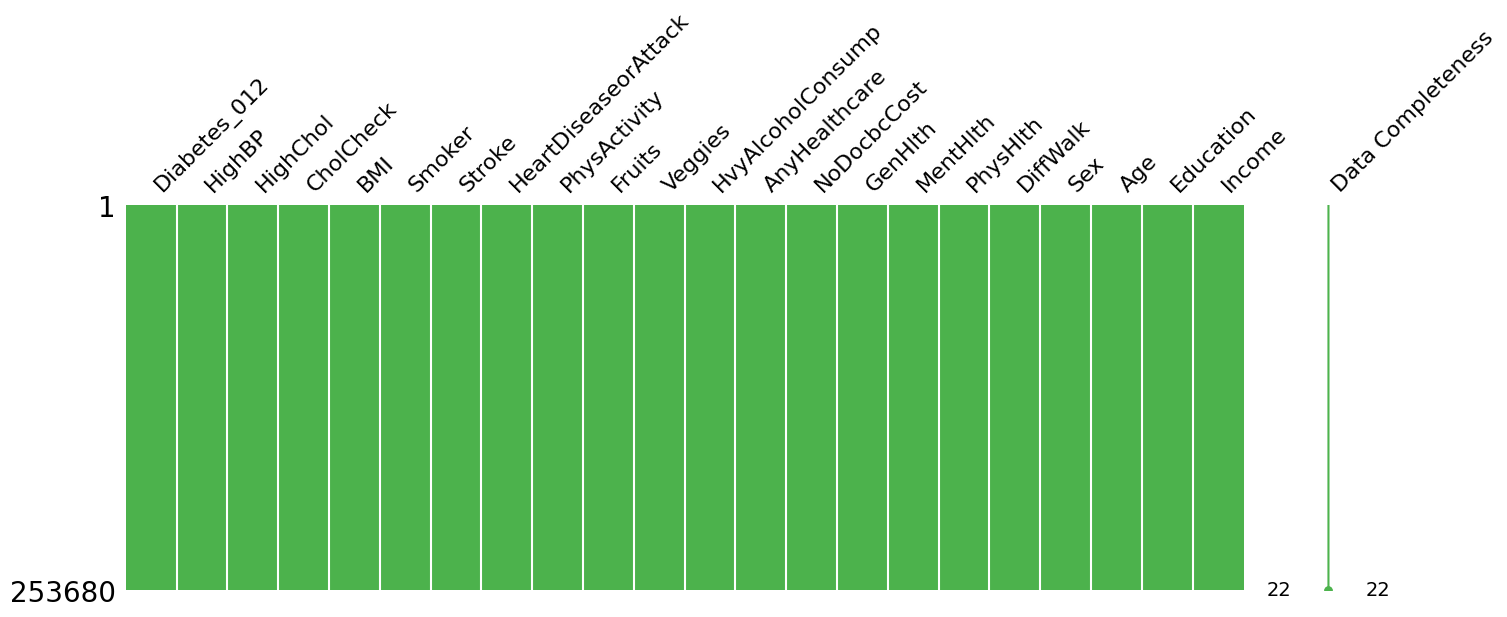

In [9]:
ms.matrix(data, figsize=(16, 5), color = (0.3, 0.7, 0.3), labels=True)

Παρακάτω βλέπουμε σε Horizontal bar chart πόσοι patients ανήκουν σε κάθε κλάση. Τα δεδομένα είναι unbalanced.

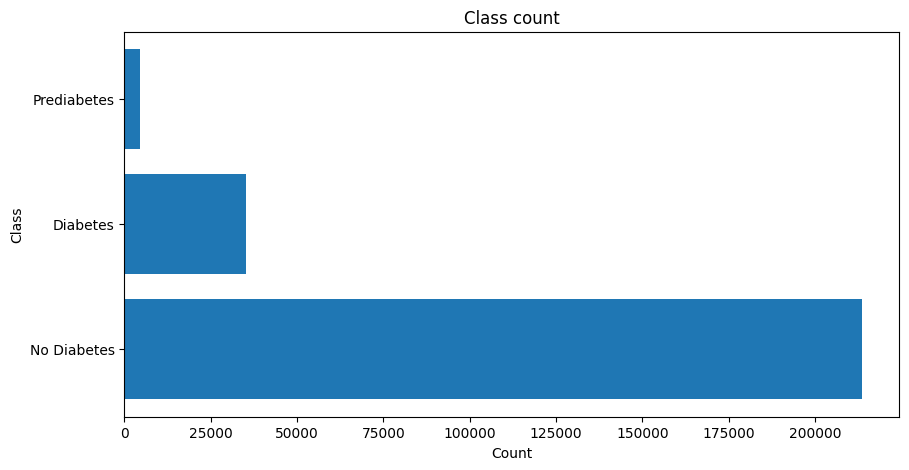

In [ ]:
mapping = {
    0: "No Diabetes",
    1: "Prediabetes",
    2: "Diabetes"
}

counts = data['Diabetes_012'].map(mapping).value_counts()

plt.figure(figsize=(10, 5))
plt.barh(counts.index, counts.values)
plt.ylabel("Class")
plt.xlabel("Count")
plt.title("Class count")
plt.show()

Επίσης, εκτυπώνοντας στατιστικά για το dataset βλέπουμε για κάθε feature το mean, standard deviation, min, 25% percentatile, median, 75% percentile και max.

- Από τα independent variables, τα features <b>ΒΜΙ, MentHealth</b> και <b>PhysHlth</b> είναι numeric. Επειδή εχουν διαφορετικές κλίμακες, θα χρειαστεί αργότερα να πραγματοποιήσουμε standardization.

- Οι μεταβλητές <b>GenHlth</b>, <b>Age</b>, <b>Education</b>, <b>Income</b> αποτελούν κατηγορηματικές μεταβλητές με πάνω από 2 κατηγορίες. Πιθανώς στην συνέχεια να χρειαστεί να δημιουργήσουμε dummy variables αν χρησιμοποιήσουμε κάποιο ταξινομητή όπως logistic regression.

- Οι υπόλοιπες μεταβλητές είναι binary categorical variables.

In [10]:
data.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000,35095.000000
mean,0.286935,0.410258,0.412965,0.963129,27.919732,0.436643,0.039094,0.086366,0.780140,0.644850,0.825445,0.057843,0.946716,0.091608,2.487961,3.312723,4.262260,0.161305,0.442969,7.885083,5.082262,6.114147
std,0.686446,0.491887,0.492374,0.188449,6.104906,0.495977,0.193821,0.280907,0.414158,0.478566,0.379591,0.233450,0.224602,0.288477,1.086563,7.433677,8.672821,0.367817,0.496744,3.098226,1.018234,2.105097
min,0.000000,0.000000,0.000000,0.000000,14.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,5.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,7.000000
75%,0.000000,1.000000,1.000000,1.000000,31.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,3.000000,2.000000,3.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,2.000000,1.000000,1.000000,1.000000,92.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Παρακάτω βλέπουμε ιστογράμματα για κάθε μεταβλητή. Παρατηρούμε πως:
- Ελάχιστα άτομα δεν έχουν ελέγξει την χολιστερίνη τα τελευταία 5 χρόνια.
- Ελάχιστα άτομα έχουν περάσει εγκεφαλικό επεισόδιο.
- Ελάχιστα άτομα έχουν coronary heart disease (CHD) ή myocardial infarction (MI)
- Λίγα άτομα δεν καταναλώνουν λαχανικά.
- Ελάχιστα άτομα καταναλώνουν πολύ αλκόολ.
- Ελάχιστα άτομα δεν έχουν κάληψη για την υγεία.
- Ελάχιστα άτομα δεν έχουν λεφτά για να πάνε στο γιατρό.
- Λίγα άτομα έχουν δυσκολία να περπατήσουν.

/tmp/ipykernel_6936/3392517228.py:3: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.
  data.hist(ax = ax)


array([[<Axes: title={'center': 'Diabetes_012'}>,
        <Axes: title={'center': 'HighBP'}>,
        <Axes: title={'center': 'HighChol'}>,
        <Axes: title={'center': 'CholCheck'}>,
        <Axes: title={'center': 'BMI'}>],
       [<Axes: title={'center': 'Smoker'}>,
        <Axes: title={'center': 'Stroke'}>,
        <Axes: title={'center': 'HeartDiseaseorAttack'}>,
        <Axes: title={'center': 'PhysActivity'}>,
        <Axes: title={'center': 'Fruits'}>],
       [<Axes: title={'center': 'Veggies'}>,
        <Axes: title={'center': 'HvyAlcoholConsump'}>,
        <Axes: title={'center': 'AnyHealthcare'}>,
        <Axes: title={'center': 'NoDocbcCost'}>,
        <Axes: title={'center': 'GenHlth'}>],
       [<Axes: title={'center': 'MentHlth'}>,
        <Axes: title={'center': 'PhysHlth'}>,
        <Axes: title={'center': 'DiffWalk'}>,
        <Axes: title={'center': 'Sex'}>, <Axes: title={'center': 'Age'}>],
       [<Axes: title={'center': 'Education'}>,
        <Axes: title={'c

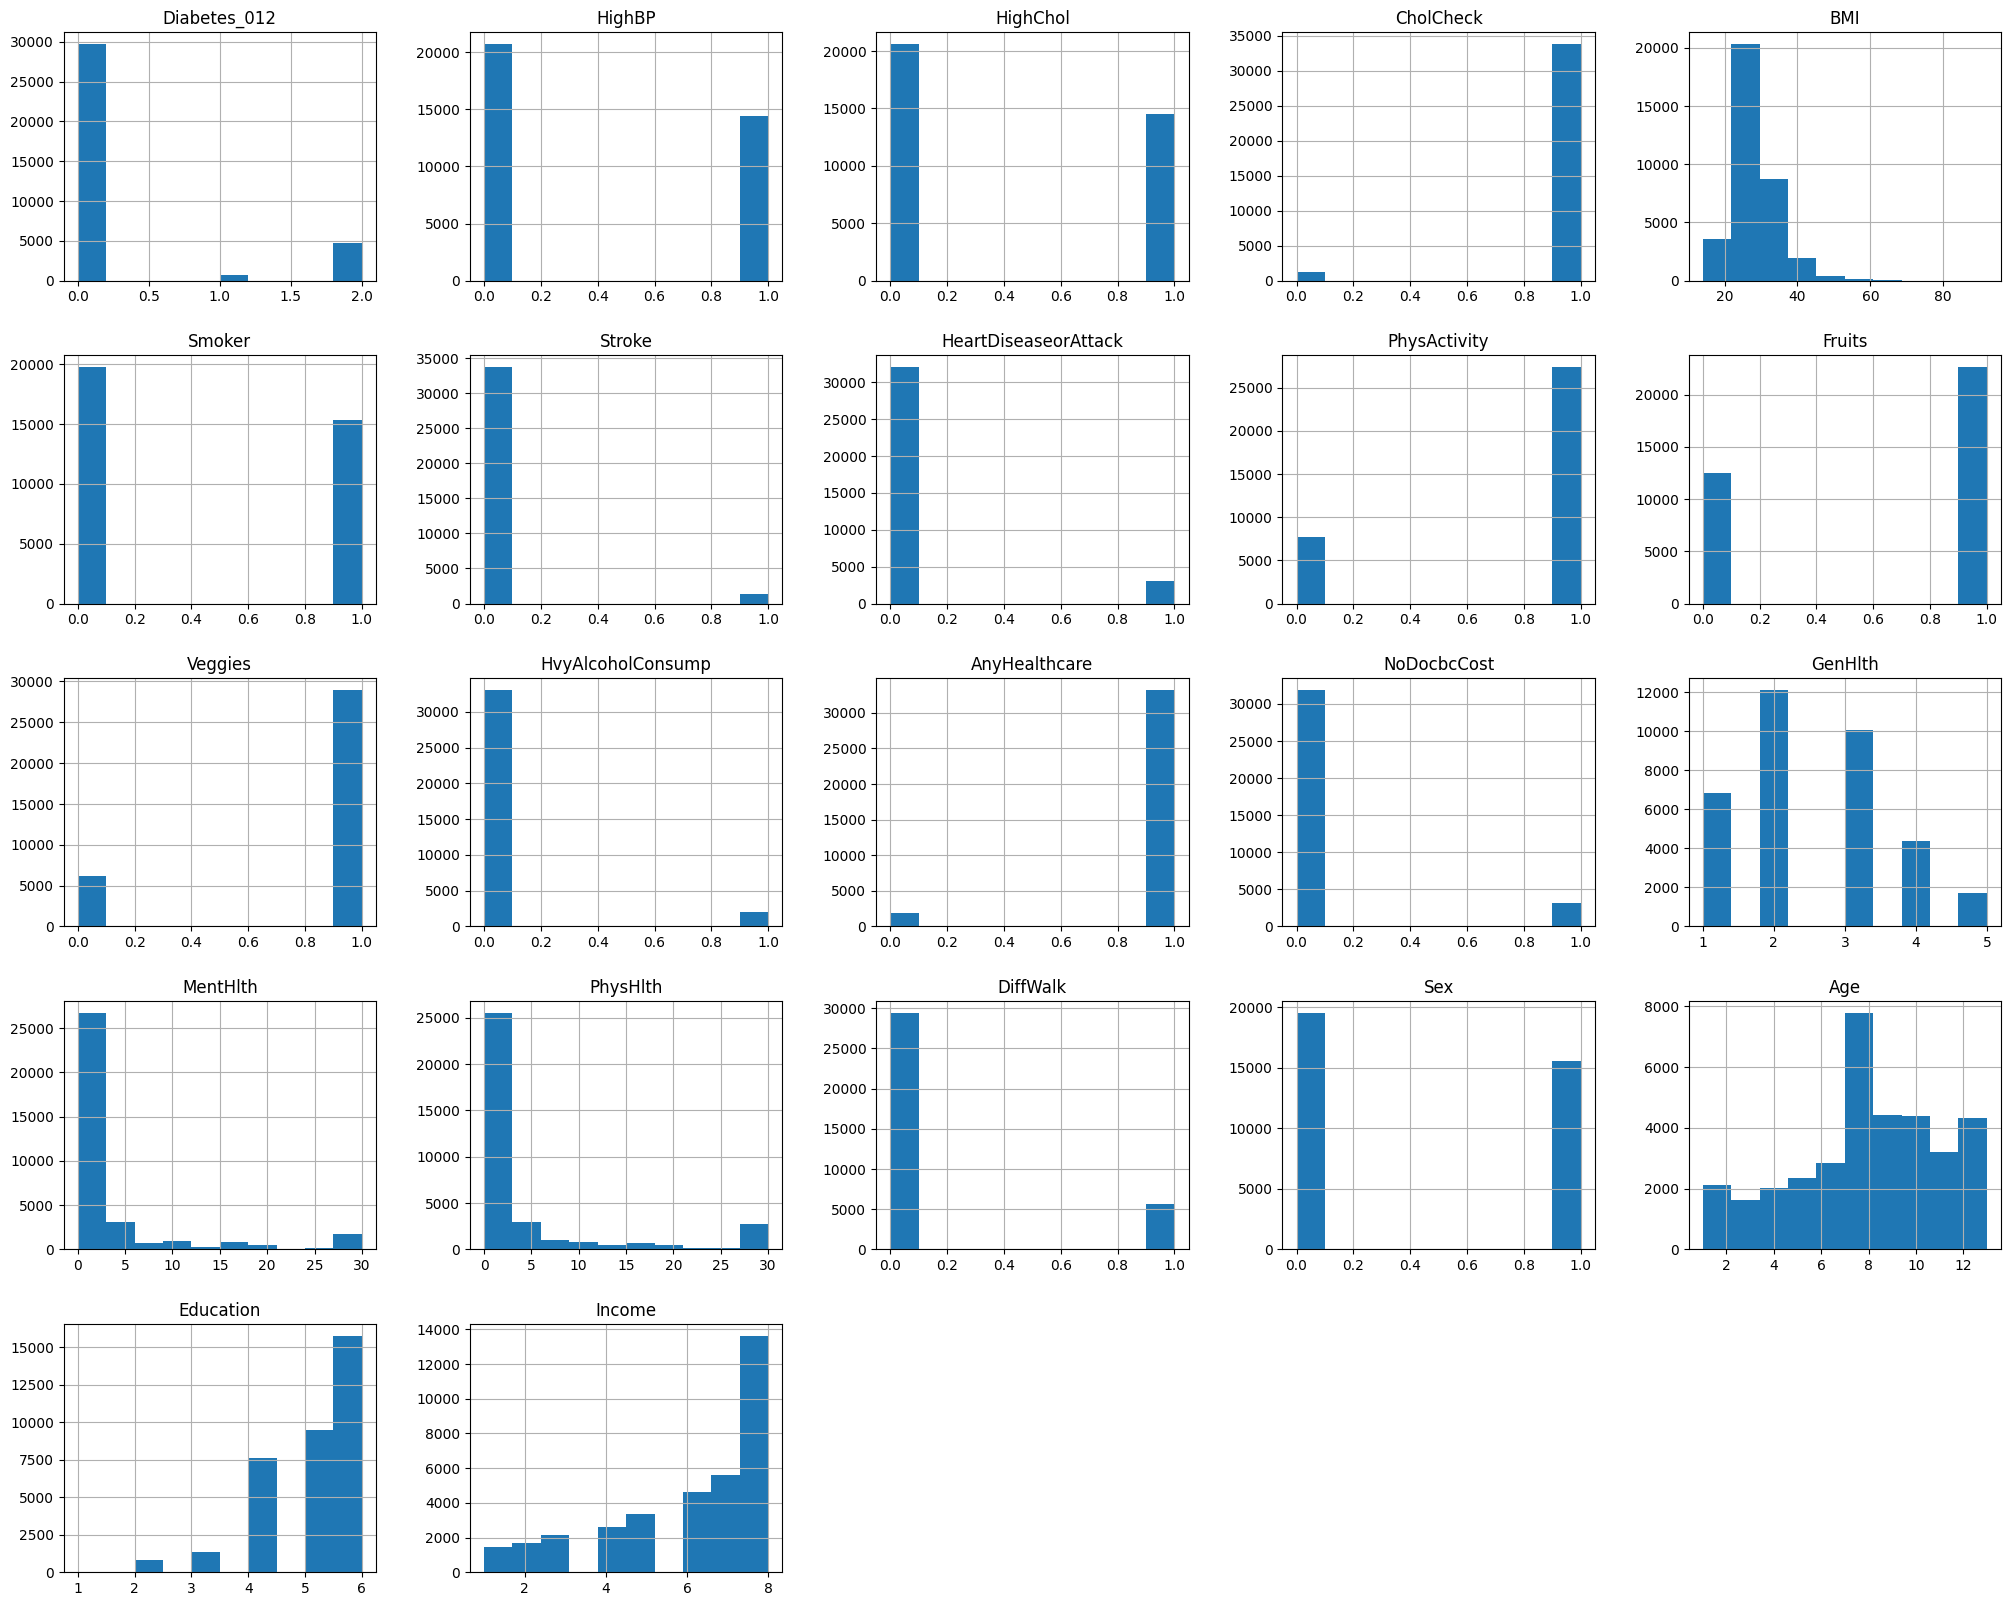

In [11]:
fig = plt.figure(figsize = (25, 20))
ax = fig.gca()
data.hist(ax = ax)

Παρακάτω φαίνονται οι συσχετίσεις των μεταβλητών. Η κλάση (Diabetes_012) δεν έχει μεγάλη συσχέτιση με κάποια συγκεκριμένη στήλη. <br>
Πιθανώς όμως να μπορούμε να βγάλουμε συμπεράσματα από διάφορες μεταβλητές. Η κλάση έχει μικρή συσχέτιση με την υγεία, την υψηλή πίεση, την χολυστερήνη, το BMI και την ηλικία. <br>

<Axes: >

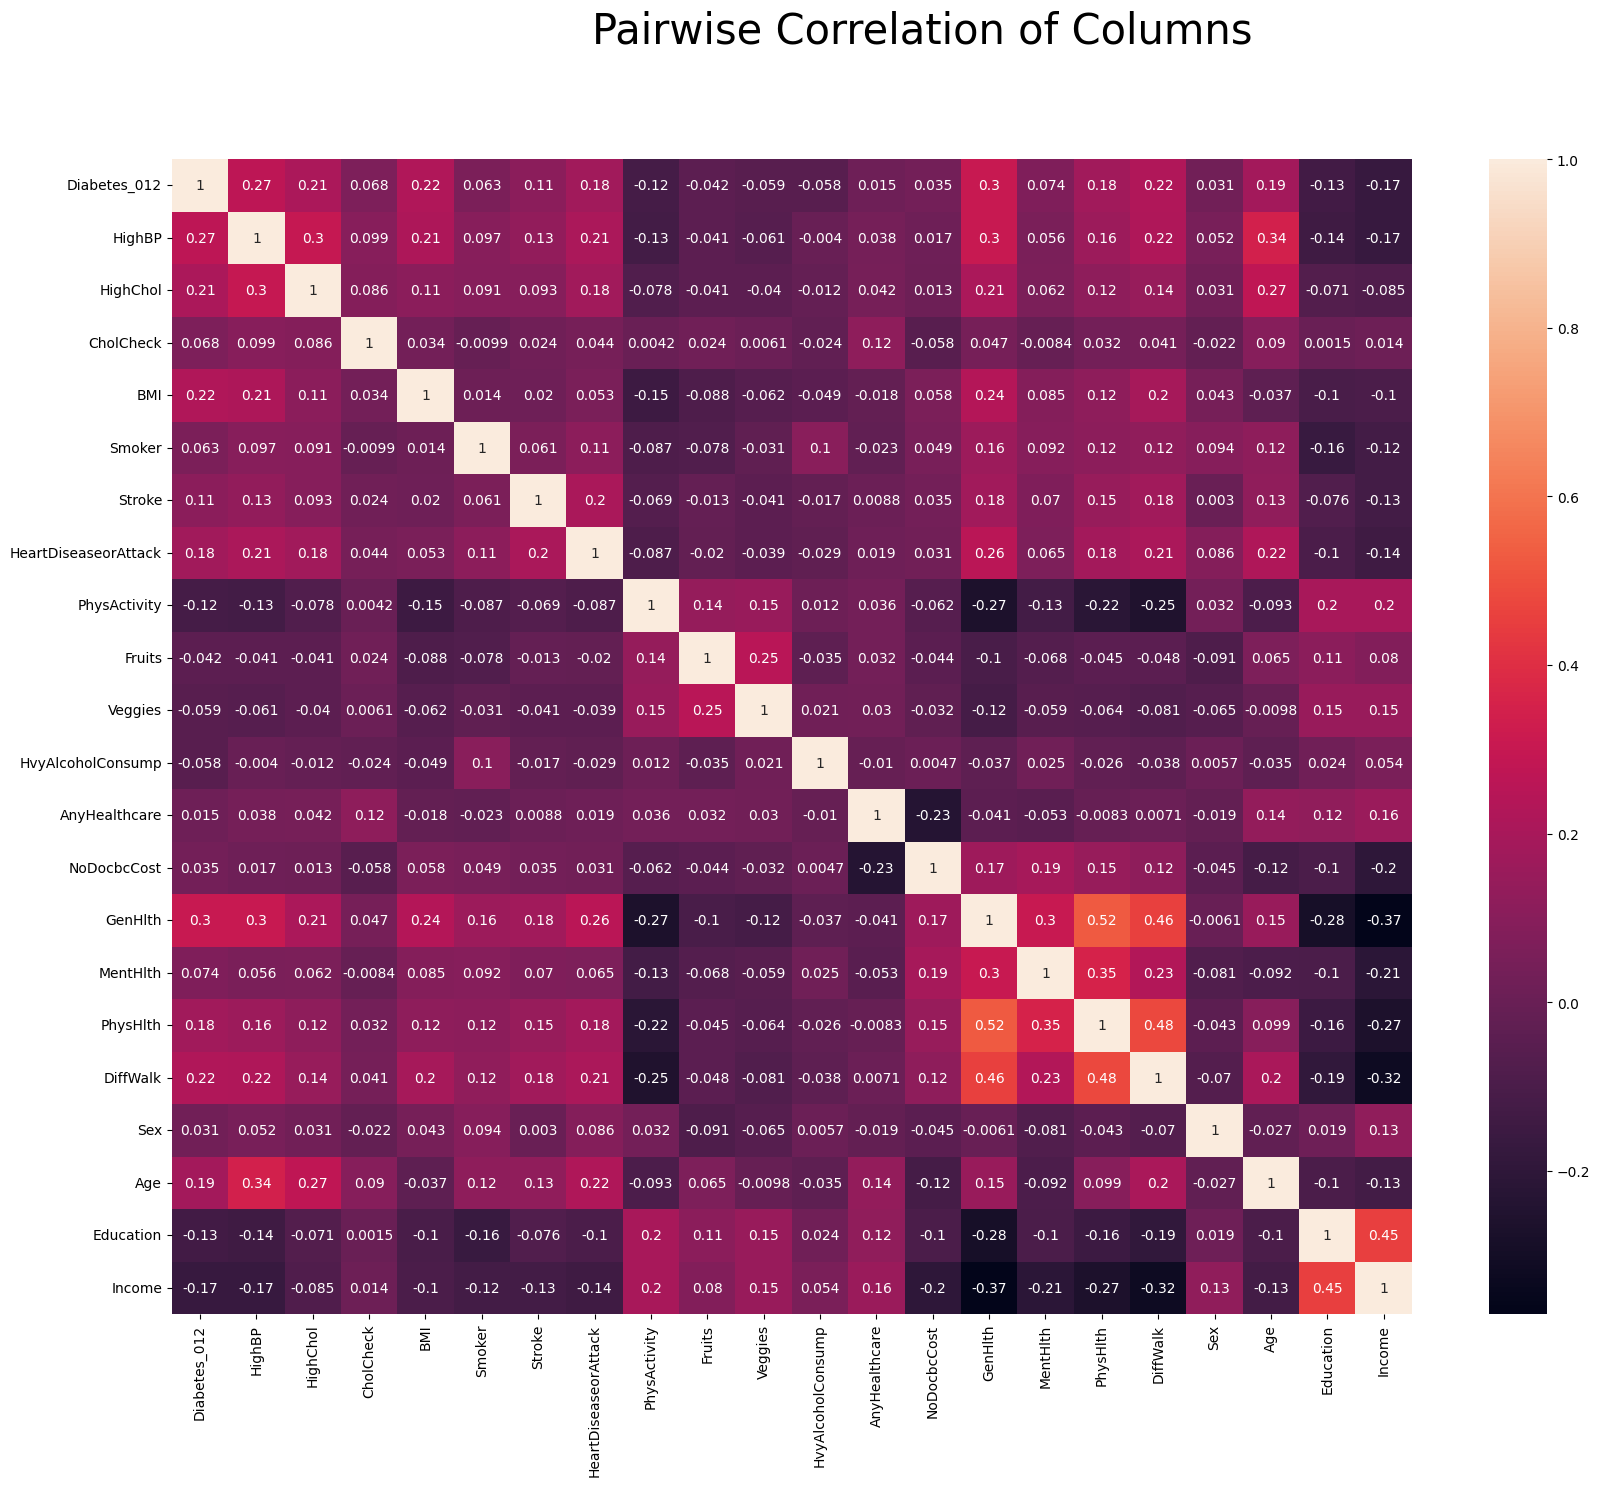

In [ ]:
corr_matrix = data.corr()
fig, ax = plt.subplots(figsize=(20,15))
fig.suptitle('Pairwise Correlation of Columns', fontsize=30)
sns.heatmap(corr_matrix, annot=True, ax=ax)

##Models

In [12]:
X=data.drop('Diabetes_012', axis=1)
y=data['Diabetes_012']

In [13]:
X.shape, y.shape

((35095, 21), (35095,))

In [15]:
# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

###XGBoost classifier

In [16]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report



# Initialize the XGBoost Classifier
# Use 'multi:softmax' for multiclass classification
# 'num_class' should be set to the number of unique classes in your target variable
xg_classifier = xgb.XGBClassifier(objective='multi:softmax', num_class=len(y.unique()), random_state=42)

# Train the model
xg_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xg = xg_classifier.predict(X_test)

# Evaluate the model
accuracy_xg = accuracy_score(y_test, y_pred_xg)
f1_xg = f1_score(y_test, y_pred_xg, average='weighted') # 'weighted' is good for multiclass
precision_xg = precision_score(y_test, y_pred_xg, average='weighted')
recall_xg = recall_score(y_test, y_pred_xg, average='weighted')

print(f"XGBoost Accuracy: {accuracy_xg:.4f}")
print(f"XGBoost F1 Score: {f1_xg:.4f}")
print(f"XGBoost Precision: {precision_xg:.4f}")
print(f"XGBoost Recall: {recall_xg:.4f}")
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xg))

XGBoost Accuracy: 0.8474
XGBoost F1 Score: 0.8140
XGBoost Precision: 0.8068
XGBoost Recall: 0.8474

XGBoost Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92      5941
         1.0       0.33      0.01      0.01       143
         2.0       0.48      0.20      0.28       935

    accuracy                           0.85      7019
   macro avg       0.56      0.39      0.41      7019
weighted avg       0.81      0.85      0.81      7019



Από το παραπάνω classification report για τον XGBoost classifier, παρατηρούμε ότι το μοντέλο συνεχίζει να έχει υψηλή ακρίβεια στην πρόβλεψη της κλάσης 0 (όχι διαβήτης), η οποία είναι η πλειοψηφούσα κλάση. Ωστόσο, η απόδοση στις μειοψηφούσες κλάσεις (προ-διαβήτης και διαβήτης) παραμένει χαμηλή, ειδικά για την κλάση 1 (προ-διαβήτης) όπου οι τιμές είναι σχεδόν μηδενικές. Αυτό υποδηλώνει ότι το μοντέλο δυσκολεύεται ακόμα να διακρίνει αυτές τις κλάσεις, παρά την προσπάθεια εξισορρόπησης των δεδομένων. Χρειάζεται περαιτέρω διερεύνηση ή τεχνικές για να βελτιωθεί η αναγνώριση των μειοψηφουσών κλάσεων.

/tmp/ipykernel_6936/3153086560.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_report_classes_xg.index, y='precision', data=df_report_classes_xg, ax=axes[0], palette='viridis')
/tmp/ipykernel_6936/3153086560.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_report_classes_xg.index, y='recall', data=df_report_classes_xg, ax=axes[1], palette='plasma')
/tmp/ipykernel_6936/3153086560.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_report_classes_xg.index, y='f1-score', data=df_report_classes_xg, ax=axes[2], palette='m

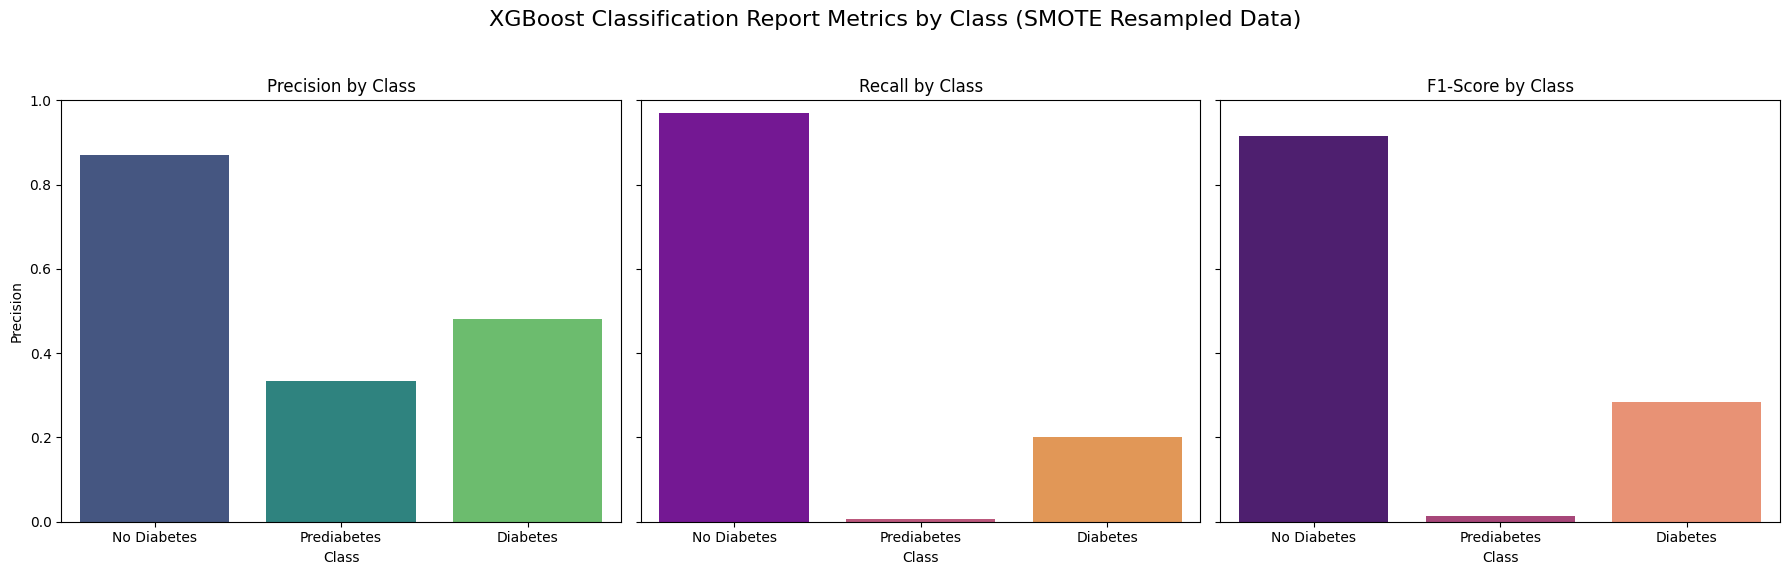

In [17]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the classification report as a dictionary
report_dict_xg = classification_report(y_test, y_pred_xg, output_dict=True)

# Convert the dictionary to a pandas DataFrame for easier plotting
df_report_xg = pd.DataFrame(report_dict_xg).transpose()

# Filter out 'accuracy', 'macro avg', 'weighted avg' rows for class-specific plots
df_report_classes_xg = df_report_xg.loc[['0.0', '1.0', '2.0']]

# Rename index for better readability
df_report_classes_xg.index = ['No Diabetes', 'Prediabetes', 'Diabetes']

# Plotting the metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('XGBoost Classification Report Metrics by Class (SMOTE Resampled Data)', fontsize=16)

# Precision plot
sns.barplot(x=df_report_classes_xg.index, y='precision', data=df_report_classes_xg, ax=axes[0], palette='viridis')
axes[0].set_title('Precision by Class')
axes[0].set_ylabel('Precision')
axes[0].set_xlabel('Class')
axes[0].set_ylim(0, 1) # Set y-limit for consistent comparison

# Recall plot
sns.barplot(x=df_report_classes_xg.index, y='recall', data=df_report_classes_xg, ax=axes[1], palette='plasma')
axes[1].set_title('Recall by Class')
axes[1].set_ylabel('Recall')
axes[1].set_xlabel('Class')
axes[1].set_ylim(0, 1)

# F1-Score plot
sns.barplot(x=df_report_classes_xg.index, y='f1-score', data=df_report_classes_xg, ax=axes[2], palette='magma')
axes[2].set_title('F1-Score by Class')
axes[2].set_ylabel('F1-Score')
axes[2].set_xlabel('Class')
axes[2].set_ylim(0, 1)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

###Random Forest Classifier

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

# Split the resampled data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42, stratify=y)

# Initialize the Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the model
rf_classifier.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_classifier.predict(X_test)

# Evaluate the model
accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average='weighted') # 'weighted' is good for multiclass
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest F1 Score: {f1_rf:.4f}")
print(f"Random Forest Precision: {precision_rf:.4f}")
print(f"Random Forest Recall: {recall_rf:.4f}")
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.8497
Random Forest F1 Score: 0.8141
Random Forest Precision: 0.8033
Random Forest Recall: 0.8497

Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.97      0.92      5941
         1.0       0.00      0.00      0.00       143
         2.0       0.52      0.19      0.28       935

    accuracy                           0.85      7019
   macro avg       0.46      0.39      0.40      7019
weighted avg       0.80      0.85      0.81      7019



/tmp/ipykernel_6936/3187919484.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_report_classes.index, y='precision', data=df_report_classes, ax=axes[0], palette='viridis')
/tmp/ipykernel_6936/3187919484.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_report_classes.index, y='recall', data=df_report_classes, ax=axes[1], palette='plasma')
/tmp/ipykernel_6936/3187919484.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_report_classes.index, y='f1-score', data=df_report_classes, ax=axes[2], palette='magma')


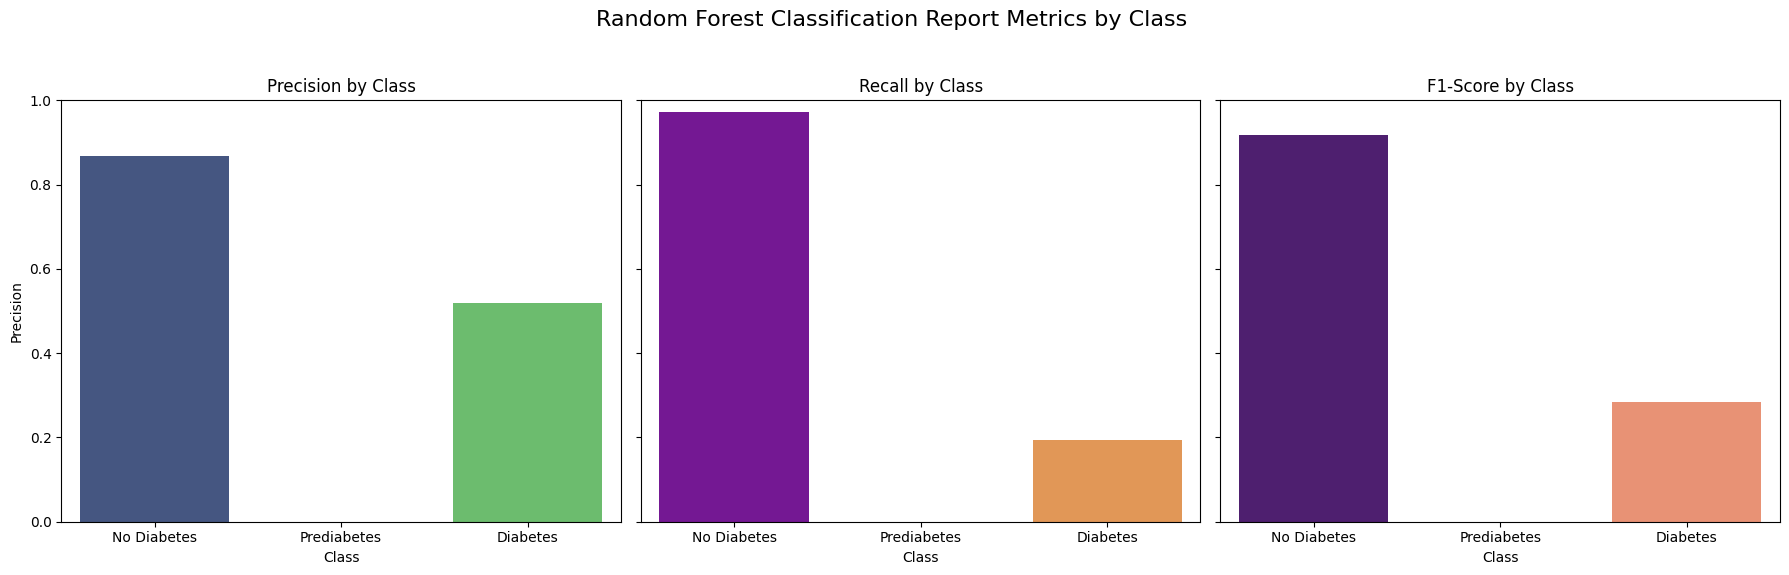

In [19]:
from sklearn.metrics import classification_report
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the classification report as a dictionary
report_dict = classification_report(y_test, y_pred_rf, output_dict=True)

# Convert the dictionary to a pandas DataFrame for easier plotting
df_report = pd.DataFrame(report_dict).transpose()

# Filter out 'accuracy', 'macro avg', 'weighted avg' rows for class-specific plots
df_report_classes = df_report.loc[['0.0', '1.0', '2.0']]

# Rename index for better readability
df_report_classes.index = ['No Diabetes', 'Prediabetes', 'Diabetes']

# Plotting the metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)
fig.suptitle('Random Forest Classification Report Metrics by Class ', fontsize=16)

# Precision plot
sns.barplot(x=df_report_classes.index, y='precision', data=df_report_classes, ax=axes[0], palette='viridis')
axes[0].set_title('Precision by Class')
axes[0].set_ylabel('Precision')
axes[0].set_xlabel('Class')
axes[0].set_ylim(0, 1) # Set y-limit for consistent comparison

# Recall plot
sns.barplot(x=df_report_classes.index, y='recall', data=df_report_classes, ax=axes[1], palette='plasma')
axes[1].set_title('Recall by Class')
axes[1].set_ylabel('Recall')
axes[1].set_xlabel('Class')
axes[1].set_ylim(0, 1)

# F1-Score plot
sns.barplot(x=df_report_classes.index, y='f1-score', data=df_report_classes, ax=axes[2], palette='magma')
axes[2].set_title('F1-Score by Class')
axes[2].set_ylabel('F1-Score')
axes[2].set_xlabel('Class')
axes[2].set_ylim(0, 1)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
plt.show()

Απο το παραπάνω classification report, παρατηρούμε ότι το μοντέλο καταφέρνει σχεδόν τέλεια (με F1-score σχεδόν 90%) να προβλέψει την κλάση 0 (δηλαδή την κλάσση των όσων δεν έχουν διαβήτη), συμπέρασμα λογικό καθώς είναι η πλειοψηφούσα κλάση. Αδυνατεί να προβλέψει καλά τις μειοψηφούσες κλάσεις, δηλαδή των όσον εμφανίζουν προδιάθεση για διαβήτη (εδώ το μοντέλο είναι σαν να μην την βλέπει καν) και τον όσων έχουν διαβήτη.  

##   Παραγωγή Synthetic Data

###  CTGAN

### SMOTE

In [20]:
from imblearn.over_sampling import SMOTE

In [21]:
data_cleaned = data.dropna()
X = data_cleaned.drop('Diabetes_012', axis=1)
y = data_cleaned['Diabetes_012']

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("Original dataset shape:")
print(y.value_counts())

print("\nResampled dataset shape:")
print(y_res.value_counts())

Original dataset shape:
Diabetes_012
0.0    29703
2.0     4678
1.0      714
Name: count, dtype: int64

Resampled dataset shape:
Diabetes_012
0.0    29703
2.0    29703
1.0    29703
Name: count, dtype: int64


Αφού εφαρμόσαμε το SMOTE, βλέπουμε την νέα κατανομή των κλάσεων. Όλες οι κλάσεις έχουν πλέον τον ίδιο αριθμό δειγμάτων, το οποίο είναι το μέγεθος της πλειοψηφούσας κλάσης στο αρχικό dataset (0: No Diabetes).

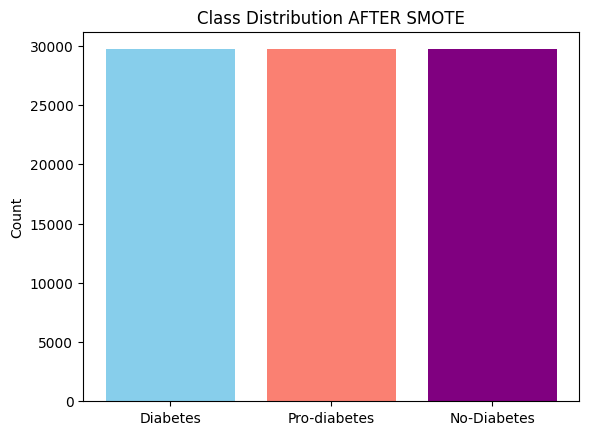

In [22]:
plt.bar(y_res.value_counts().index, y_res.value_counts().values,
        color=['skyblue','purple', 'salmon'])
plt.xticks([0,1, 2], ['Diabetes', 'Pro-diabetes', 'No-Diabetes'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER SMOTE")
plt.show()

### Training Classifiers with SMOTE-Resampled Data

In [25]:
# Split the SMOTE-resampled data into training and testing sets
# We will use the X_res and y_res generated by SMOTE earlier
from sklearn.model_selection import train_test_split

X_train_smote, X_test_smote, y_train_smote, y_test_smote = train_test_split(X_res, y_res, test_size=0.2, random_state=42, stratify=y_res)

print(f"Shape of X_train_smote: {X_train_smote.shape}")
print(f"Shape of y_train_smote: {y_train_smote.shape}")
print(f"Shape of X_test_smote: {X_test_smote.shape}")
print(f"Shape of y_test_smote: {y_test_smote.shape}")

Shape of X_train_smote: (71287, 21)
Shape of y_train_smote: (71287,)
Shape of X_test_smote: (17822, 21)
Shape of y_test_smote: (17822,)


#### XGBoost Classifier with SMOTE

In [26]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report

# Initialize the XGBoost Classifier with SMOTE data
xg_classifier_smote = xgb.XGBClassifier(objective='multi:softmax', num_class=len(y_res.unique()), random_state=42)

# Train the model on SMOTE-resampled training data
xg_classifier_smote.fit(X_train_smote, y_train_smote)

# Make predictions on the SMOTE-resampled test set
y_pred_xg_smote = xg_classifier_smote.predict(X_test_smote)

# Evaluate the model
accuracy_xg_smote = accuracy_score(y_test_smote, y_pred_xg_smote)
f1_xg_smote = f1_score(y_test_smote, y_pred_xg_smote, average='weighted')
precision_xg_smote = precision_score(y_test_smote, y_pred_xg_smote, average='weighted')
recall_xg_smote = recall_score(y_test_smote, y_pred_xg_smote, average='weighted')

print(f"XGBoost (SMOTE) Accuracy: {accuracy_xg_smote:.4f}")
print(f"XGBoost (SMOTE) F1 Score: {f1_xg_smote:.4f}")
print(f"XGBoost (SMOTE) Precision: {precision_xg_smote:.4f}")
print(f"XGBoost (SMOTE) Recall: {recall_xg_smote:.4f}")
print("\nXGBoost (SMOTE) Classification Report:")
print(classification_report(y_test_smote, y_pred_xg_smote))

XGBoost (SMOTE) Accuracy: 0.9121
XGBoost (SMOTE) F1 Score: 0.9112
XGBoost (SMOTE) Precision: 0.9142
XGBoost (SMOTE) Recall: 0.9121

XGBoost (SMOTE) Classification Report:
              precision    recall  f1-score   support

         0.0       0.87      0.96      0.92      5940
         1.0       0.93      0.95      0.94      5941
         2.0       0.93      0.82      0.87      5941

    accuracy                           0.91     17822
   macro avg       0.91      0.91      0.91     17822
weighted avg       0.91      0.91      0.91     17822



#### Random Forest Classifier with SMOTE

In [27]:
from sklearn.ensemble import RandomForestClassifier

# Initialize the Random Forest Classifier with SMOTE data
rf_classifier_smote = RandomForestClassifier(random_state=42)

# Train the model on SMOTE-resampled training data
rf_classifier_smote.fit(X_train_smote, y_train_smote)

# Make predictions on the SMOTE-resampled test set
y_pred_rf_smote = rf_classifier_smote.predict(X_test_smote)

# Evaluate the model
accuracy_rf_smote = accuracy_score(y_test_smote, y_pred_rf_smote)
f1_rf_smote = f1_score(y_test_smote, y_pred_rf_smote, average='weighted')
precision_rf_smote = precision_score(y_test_smote, y_pred_rf_smote, average='weighted')
recall_rf_smote = recall_score(y_test_smote, y_pred_rf_smote, average='weighted')

print(f"Random Forest (SMOTE) Accuracy: {accuracy_rf_smote:.4f}")
print(f"Random Forest (SMOTE) F1 Score: {f1_rf_smote:.4f}")
print(f"Random Forest (SMOTE) Precision: {precision_rf_smote:.4f}")
print(f"Random Forest (SMOTE) Recall: {recall_rf_smote:.4f}")
print("\nRandom Forest (SMOTE) Classification Report:")
print(classification_report(y_test_smote, y_pred_rf_smote))

Random Forest (SMOTE) Accuracy: 0.9407
Random Forest (SMOTE) F1 Score: 0.9409
Random Forest (SMOTE) Precision: 0.9426
Random Forest (SMOTE) Recall: 0.9407

Random Forest (SMOTE) Classification Report:
              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      5940
         1.0       0.99      0.97      0.98      5941
         2.0       0.95      0.89      0.92      5941

    accuracy                           0.94     17822
   macro avg       0.94      0.94      0.94     17822
weighted avg       0.94      0.94      0.94     17822



### Σύγκριση Ακρίβειας Μοντέλων (με SMOTE)

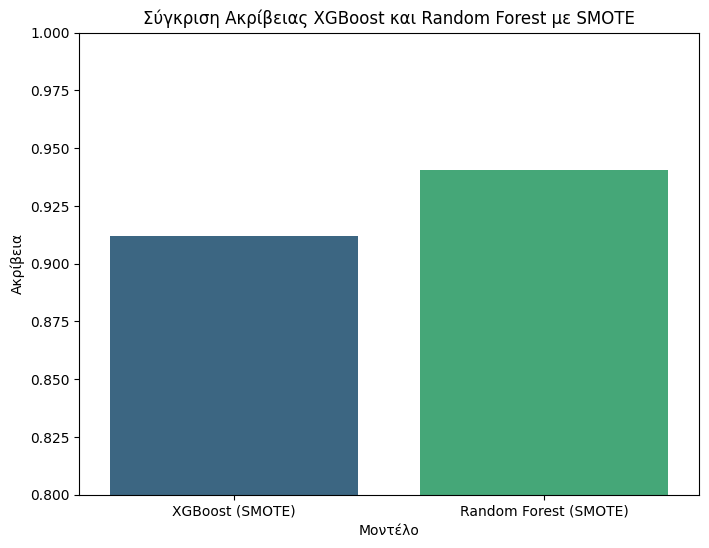

In [30]:
model_names = ['XGBoost (SMOTE)', 'Random Forest (SMOTE)']
accuracies = [accuracy_xg_smote, accuracy_rf_smote]

plt.figure(figsize=(8, 6))
sns.barplot(x=model_names, y=accuracies, hue=model_names, palette='viridis', legend=False)
plt.ylim(0.8, 1.0) # Set a reasonable y-limit for better comparison
plt.title('Σύγκριση Ακρίβειας XGBoost και Random Forest με SMOTE')
plt.ylabel('Ακρίβεια')
plt.xlabel('Μοντέλο')
plt.show()

####AADASYN SMOTE


ο ADASYN (Adaptive Synthetic Sampling - Προσαρμοστική Συνθετική Δειγματοληψία) είναι μια βελτιωμένη έκδοση του SMOTE που εστιάζει αυτόματα περισσότερο στα δείγματα της μειοψηφούσας κλάσης που είναι δύσκολο να μάθει ένα μοντέλο. Αντί να δημιουργεί συνθετικά δείγματα ομοιόμορφα, το ADASYN δημιουργεί περισσότερα νέα δείγματα για τα σημεία της μειοψηφούσας κλάσης που βρίσκονται κοντά στα όρια απόφασης, όπου το μοντέλο συνήθως κάνει περισσότερα λάθη.

Πώς λειτουργεί:

1. Υπολογίζει το επίπεδο δυσκολίας για κάθε δείγμα της μειοψηφούσας κλάσης. Εδώ, τα δείγματα που περιβάλλονται από δείγματα της πλειοψηφούσας κλάσης θεωρούνται πιο δύσκολο να μάθουν.
2. Αποδίδει υψηλότερα βάρη στα δύσκολα δείγματα, ώστε να δημιουργηθούν περισσότερα συνθετικά παραδείγματα γύρω τους.
3. Δημιουργεί συνθετικά δείγματα παρεμβάλλοντας μεταξύ κάθε δύσκολου δείγματος και των πλησιέστερων γειτόνων του από τη μειοψηφούσα κλάση.

Το τελικό σύνολο δεδομένων έχει περισσότερα νέα δείγματα κοντά στα όρια απόφασης, βελτιώνοντας την ικανότητα του μοντέλου να ταξινομεί τις περιοχές που είναι πιο απαιτητικές.



In [23]:
from imblearn.over_sampling import ADASYN

adasyn = ADASYN(sampling_strategy='minority', random_state=42)
X_train_adasyn, y_train_adasyn = adasyn.fit_resample(X_train, y_train)

print("Class distribution AFTER ADASYN:")
print(y_train_adasyn.value_counts())

Class distribution AFTER ADASYN:
Diabetes_012
1.0    23845
0.0    23762
2.0     3743
Name: count, dtype: int64


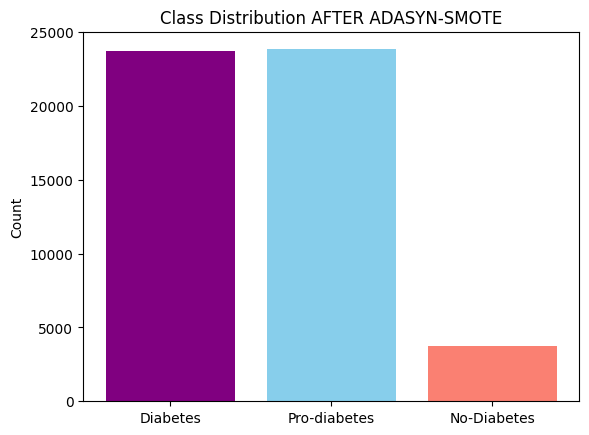

In [24]:
plt.bar(y_train_adasyn.value_counts().index, y_train_adasyn.value_counts().values,
        color=['skyblue','purple', 'salmon'])
plt.xticks([0,1,2], ['Diabetes', 'Pro-diabetes', 'No-Diabetes'])
plt.ylabel("Count")
plt.title("Class Distribution AFTER ADASYN-SMOTE")
plt.show()

### Variational Autoencoder (VAE)